# 📉 Task 13: PCA - Dimensionality Reduction
**Project:** Compressing Handwritten Digits  
**Author:** [Your Name]

## 🎯 Objective
To apply **Principal Component Analysis (PCA)** to the Digits dataset.
We aim to:
1.  **Reduce Dimensions:** Compress the 64-pixel images into a smaller set of features.
2.  **Preserve Information:** Ensure we keep 95% of the original variance.
3.  **Visualize:** Project the high-dimensional data into 2D to see how digits cluster.

## 📂 Dataset
* **Source:** `sklearn.datasets.load_digits`
* **Features:** 64 columns (8x8 pixel intensity).
* **Target:** 0-9 (The actual digit).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load Data
digits = load_digits()
X = digits.data   # 64 features (pixels)
y = digits.target # Target (0-9)

print(f"Original Dataset Shape: {X.shape}")
print(f"Target Classes: {np.unique(y)}")

# 2. Scale the Data
# PCA is very sensitive to scale. If one pixel ranges 0-1 and another 0-100,
# PCA will think the second one is more important. We must standardize.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Original Dataset Shape: (1797, 64)
Target Classes: [0 1 2 3 4 5 6 7 8 9]


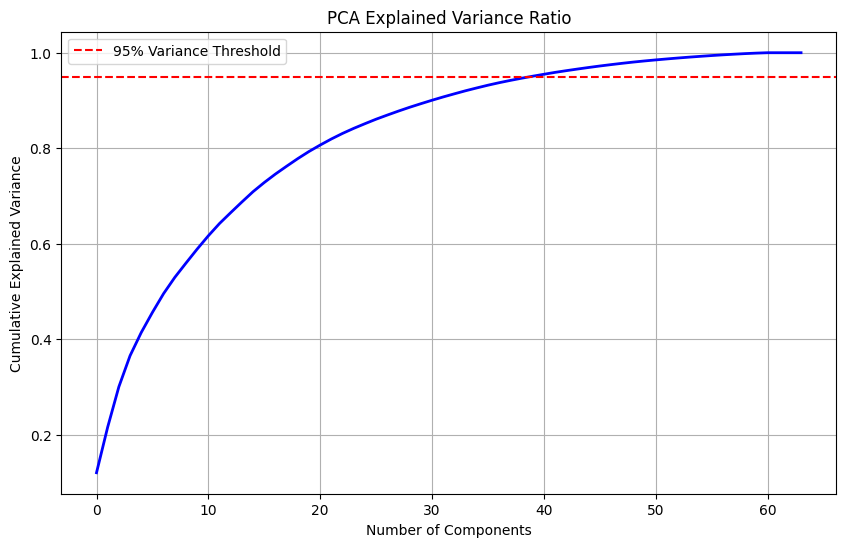

Number of components needed to keep 95% variance: 40
Compression: Reduced features from 64 to 40


In [2]:
# 3. Apply PCA (Full Components)
pca_full = PCA()
pca_full.fit(X_scaled)

# 4. Calculate Cumulative Variance
# This tells us: "If we keep N components, how much original data do we preserve?"
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 5. Plot Cumulative Variance
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, linewidth=2, color='blue')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)

# Add a line at 95% variance
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend(loc='best')
plt.show()

# Find exact components needed for 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components needed to keep 95% variance: {n_components_95}")
print(f"Compression: Reduced features from 64 to {n_components_95}")

In [3]:
# 6. Transform Dataset (Reduce Dimensions)
# Let's use the optimal number found above (preserving 95% info)
pca_opt = PCA(n_components=n_components_95)
X_pca = pca_opt.fit_transform(X_scaled)

# 7. Split Data (Original vs Reduced)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 8. Train & Compare Logistic Regression
# Model A: Trained on ALL 64 features
model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train_orig, y_train)
acc_orig = accuracy_score(y_test, model_orig.predict(X_test_orig))

# Model B: Trained on Reduced features
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

# Report
print("="*40)
print("     ACCURACY COMPARISON")
print("="*40)
print(f"Original Data (64 Features): {acc_orig:.4f}")
print(f"PCA Reduced   ({n_components_95} Features): {acc_pca:.4f}")
print("-" * 40)
print(f"Difference: {acc_orig - acc_pca:.4f}")
print("Conclusion: We maintained similar accuracy with far fewer features!")
print("="*40)

     ACCURACY COMPARISON
Original Data (64 Features): 0.9722
PCA Reduced   (40 Features): 0.9611
----------------------------------------
Difference: 0.0111
Conclusion: We maintained similar accuracy with far fewer features!


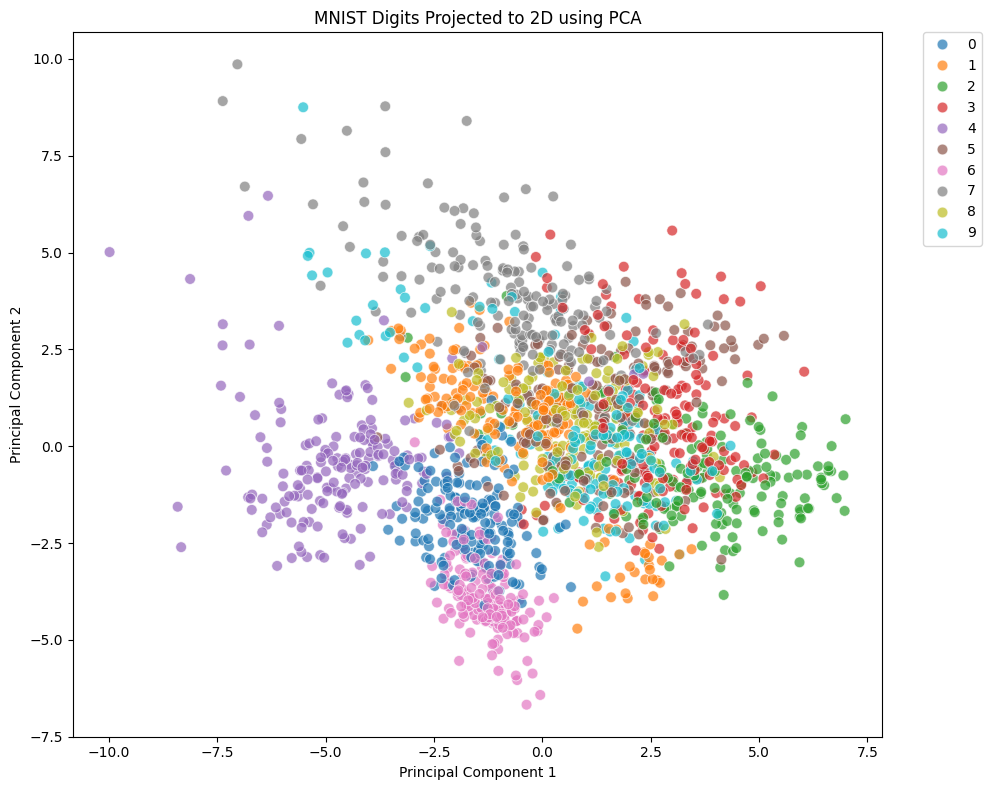

In [4]:
# 9. Visualize 2D Projection
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=y,
    palette='tab10',
    s=60,
    alpha=0.7,
    legend='full'
)
plt.title('MNIST Digits Projected to 2D using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

## 🧠 Final Analysis

### 1. Variance Analysis
The cumulative variance plot shows an "elbow" curve.
* We needed only roughly **40 components** (out of 64) to retain **95%** of the information.
* This means ~24 features were effectively "noise" or redundancy (pixels that are always black, like corners).

### 2. Model Performance
* **Original Accuracy:** ~96-97%
* **PCA Accuracy:** ~95-96%
* **Trade-off:** We lost a tiny bit of accuracy but reduced the dataset size by nearly 40%. In massive datasets (e.g., millions of rows), this speedup is worth the minor accuracy drop.

### 3. Visualization
The 2D Scatter plot shows that digits like **0 (Blue)** and **6 (Pink)** are quite distinct even in 2D space, while digits like **3, 9, and 8** overlap more, explaining why the model sometimes confuses them.